# EDA — Dataset 1 (Emergency Vehicle Siren Sounds)

Dataset **clean** (tanpa overlay noise), 3 kelas: `ambulance`, `firetruck`, `traffic`.

Perannya di project: **sumber training untuk robustness study** — model dilatih di sini (kondisi bersih),
lalu dievaluasi di D2 (kondisi berisik) untuk mengukur performance gap.

## Yang dicari di notebook ini

1. Integritas file — ada yang corrupt / duplikat?
2. Konsistensi format — sample rate, channel, durasi seragam?
3. Keseimbangan kelas
4. Karakter akustik tiap kelas — apa yang membedakan sirine dari traffic?

## Struktur folder

```
Dataset/Dataset1/sounds/
├── ambulance/   sound_1.wav ... sound_200.wav  (+ .png spectrogram bawaan)
├── firetruck/
└── traffic/
```

File `.png` dan `.py` bawaan dataset diabaikan — kita hanya baca `.wav`.

In [5]:
import hashlib
import wave
import warnings
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# ------------------------------------------------------------------ config
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
D1_DIR = ROOT / "Dataset" / "Dataset1" / "sounds"
FIG_DIR = ROOT / "figures" / "eda_d1"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ["ambulance", "firetruck", "traffic"]
PALETTE = dict(zip(CLASSES, sns.color_palette("Set2", len(CLASSES))))

# parameter analisis (samakan dengan pipeline training)
SR = 22050
DURATION = 3.0
N_FFT, HOP, N_MELS = 1024, 512, 64

assert D1_DIR.exists(), f"folder tidak ditemukan: {D1_DIR}"
print(f"dataset : {D1_DIR}")
print(f"figures : {FIG_DIR}")

dataset : d:\Coding Vscode\Siren Classification\Dataset\Dataset1\sounds
figures : d:\Coding Vscode\Siren Classification\figures\eda_d1


d:\Coding Vscode\Siren Classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1 · Inventaris file

Baca header WAV pakai modul `wave` (stdlib) — jauh lebih cepat dari `librosa.load` karena
tidak perlu decode isi audionya. Cukup untuk cek sample rate, channel, dan durasi.

In [6]:
def read_wav_header(path: Path) -> dict:
    """Metadata WAV tanpa decode audio. Return dict kosong kalau file rusak."""
    try:
        with wave.open(str(path), "rb") as w:
            n_frames = w.getnframes()
            sr = w.getframerate()
            return {
                "sample_rate": sr,
                "channels": w.getnchannels(),
                "bit_depth": w.getsampwidth() * 8,
                "n_frames": n_frames,
                "duration": n_frames / sr if sr else 0.0,
                "readable": True,
            }
    except Exception as e:
        return {"sample_rate": None, "channels": None, "bit_depth": None,
                "n_frames": None, "duration": None, "readable": False,
                "error": str(e)}


def build_inventory(base_dir: Path, classes: list) -> pd.DataFrame:
    """Satu baris per file .wav: identitas + metadata header + hash isi."""
    rows = []
    for label in classes:
        folder = base_dir / label
        for f in tqdm(sorted(folder.glob("*.wav")), desc=label, leave=False):
            row = {
                "filename": f.name,
                "label": label,
                "path": str(f),
                "size_kb": round(f.stat().st_size / 1024, 1),
                "md5": hashlib.md5(f.read_bytes()).hexdigest(),
            }
            row.update(read_wav_header(f))
            rows.append(row)
    return pd.DataFrame(rows)


df = build_inventory(D1_DIR, CLASSES)
print(f"total file .wav : {len(df)}")
df.head()

total file .wav : 600


,filename,label,path,size_kb,md5,sample_rate,channels,bit_depth,n_frames,duration,readable
0,sound_1.wav,ambulance,d:\Coding Vscode\Siren Classification\Dataset\...,516.9,b564f5ccfb25ea8fd3908204b039d7b1,44100,2,16,132300,3.0,True
1,sound_10.wav,ambulance,d:\Coding Vscode\Siren Classification\Dataset\...,516.9,1151028dfe391b7786445b516aefcf08,44100,2,16,132300,3.0,True
2,sound_100.wav,ambulance,d:\Coding Vscode\Siren Classification\Dataset\...,516.9,276511eae2d37ba077baeef7a23e3c25,44100,2,16,132300,3.0,True
3,sound_101.wav,ambulance,d:\Coding Vscode\Siren Classification\Dataset\...,516.9,89d33c2925a5d9a36a3154795c6bd4dc,44100,2,16,132300,3.0,True
4,sound_102.wav,ambulance,d:\Coding Vscode\Siren Classification\Dataset\...,516.9,e94cbf1b660db1b85e53167fa69c0436,44100,2,16,132300,3.0,True


---
## 2 · Cek integritas

Tiga hal yang bisa merusak eksperimen kalau lolos ke tahap training:

- **file corrupt** → crash di tengah training
- **file duplikat** → satu rekaman muncul di train *dan* test, akurasi jadi optimistis palsu
- **audio senyap** → sampel tanpa informasi, menambah noise ke gradien

In [7]:
# --- 2a. file corrupt ---
corrupt = df[~df.readable]
print(f"file tidak terbaca : {len(corrupt)}")
if len(corrupt):
    display(corrupt[["filename", "label", "error"]])

# --- 2b. duplikat (hash isi file, bukan nama) ---
dup_mask = df.duplicated(subset="md5", keep=False)
dups = df[dup_mask].sort_values("md5")
print(f"\nfile duplikat      : {len(dups)} "
      f"({df.md5.duplicated().sum()} bisa di-drop)")
if len(dups):
    display(dups.groupby("md5").agg(
        files=("filename", list), label=("label", "first"), n=("filename", "size")
    ).reset_index(drop=True))

file tidak terbaca : 0

file duplikat      : 8 (4 bisa di-drop)


,files,label,n
0,"[sound_129.wav, sound_130.wav]",ambulance,2
1,"[sound_73.wav, sound_76.wav]",ambulance,2
2,"[sound_75.wav, sound_78.wav]",ambulance,2
3,"[sound_74.wav, sound_77.wav]",ambulance,2


In [8]:
# --- 2c. audio senyap / hampir senyap ---
# Perlu decode audio, jadi kita ukur RMS sekalian untuk analisis nanti.
def load_audio(path: str) -> np.ndarray:
    """Mono, 22050 Hz, peak-normalized — sama seperti pipeline training."""
    y, _ = librosa.load(path, sr=SR, mono=True, duration=DURATION)
    peak = np.abs(y).max()
    return y / peak if peak > 0 else y


def raw_rms(path: str) -> float:
    """RMS sebelum normalisasi — untuk deteksi file senyap."""
    y, _ = librosa.load(path, sr=SR, mono=True, duration=DURATION)
    return float(np.sqrt(np.mean(y ** 2)))


tqdm.pandas(desc="hitung RMS")
df["rms_raw"] = df.path.progress_apply(raw_rms)

SILENCE_THRESHOLD = 1e-4
silent = df[df.rms_raw < SILENCE_THRESHOLD]
print(f"file senyap (RMS < {SILENCE_THRESHOLD}) : {len(silent)}")
if len(silent):
    display(silent[["filename", "label", "rms_raw"]])

hitung RMS: 100%|██████████| 600/600 [00:03<00:00, 173.50it/s]

file senyap (RMS < 0.0001) : 0


---
## 3 · Konsistensi format

Kalau sample rate campur-campur, resampling bukan opsional — itu wajib, dan harus dilakukan
**sebelum** ekstraksi fitur supaya sumbu frekuensi log-mel konsisten antar file.

In [9]:
print("— sample rate —")
print(pd.crosstab(df.label, df.sample_rate, margins=True, margins_name="TOTAL"))
print("\n— channel (1=mono, 2=stereo) —")
print(pd.crosstab(df.label, df.channels, margins=True, margins_name="TOTAL"))
print("\n— bit depth —")
print(pd.crosstab(df.label, df.bit_depth, margins=True, margins_name="TOTAL"))

— sample rate —
sample_rate  22050  44100  48000  TOTAL
label                                  
ambulance        6    141     53    200
firetruck        0    141     59    200
traffic          0    200      0    200
TOTAL            6    482    112    600

— channel (1=mono, 2=stereo) —
channels    1    2  TOTAL
label                    
ambulance  15  185    200
firetruck   0  200    200
traffic     0  200    200
TOTAL      15  585    600

— bit depth —
bit_depth   16  TOTAL
label                
ambulance  200    200
firetruck  200    200
traffic    200    200
TOTAL      600    600


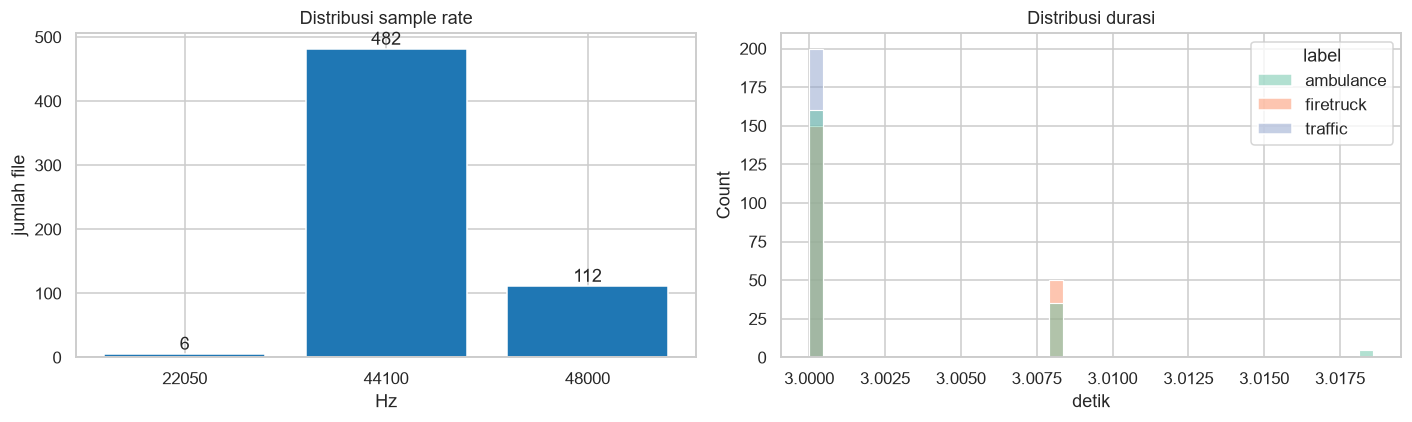

count    600.000
mean       3.001
std        0.003
min        3.000
25%        3.000
50%        3.000
75%        3.000
max        3.019

file yang durasinya bukan ~3.0 detik : 0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sr_counts = df.sample_rate.value_counts().sort_index()
axes[0].bar([str(s) for s in sr_counts.index], sr_counts.values, color="tab:blue")
axes[0].set(title="Distribusi sample rate", xlabel="Hz", ylabel="jumlah file")
for i, v in enumerate(sr_counts.values):
    axes[0].text(i, v, str(v), ha="center", va="bottom")

sns.histplot(data=df, x="duration", hue="label", palette=PALETTE,
             bins=40, ax=axes[1])
axes[1].set(title="Distribusi durasi", xlabel="detik")

plt.tight_layout()
plt.savefig(FIG_DIR / "format_consistency.png", bbox_inches="tight")
plt.show()

print(df.duration.describe().round(3).to_string())
off = df[(df.duration - 3.0).abs() > 0.05]
print(f"\nfile yang durasinya bukan ~3.0 detik : {len(off)}")

---
## 4 · Distribusi kelas

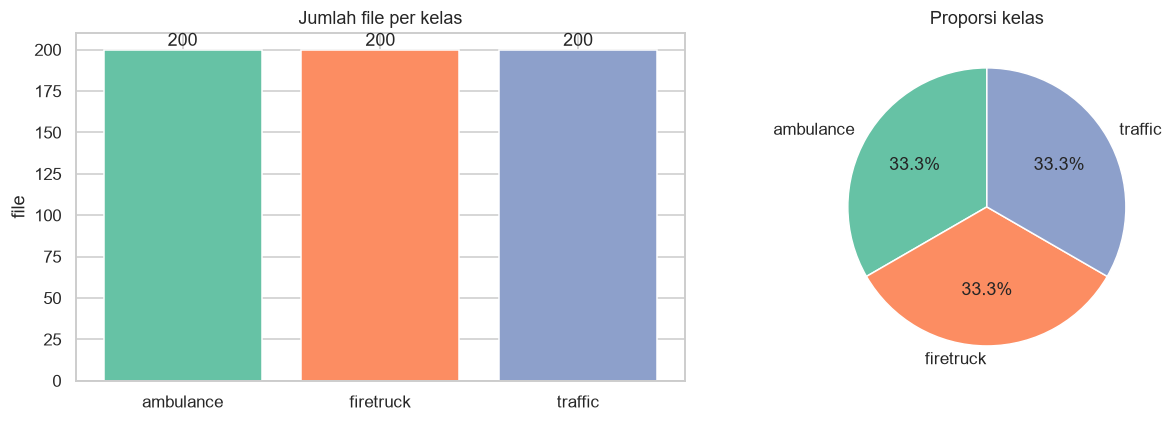

rasio ketidakseimbangan (max/min) = 1.00
→ seimbang, tidak perlu class weighting


In [7]:
counts = df.label.value_counts().reindex(CLASSES)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(counts.index, counts.values,
            color=[PALETTE[c] for c in counts.index])
axes[0].set(title="Jumlah file per kelas", ylabel="file")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, str(v), ha="center", va="bottom")

axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=[PALETTE[c] for c in counts.index], startangle=90)
axes[1].set_title("Proporsi kelas")

plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", bbox_inches="tight")
plt.show()

imbalance = counts.max() / counts.min()
print(f"rasio ketidakseimbangan (max/min) = {imbalance:.2f}")
print("→ seimbang, tidak perlu class weighting" if imbalance < 1.5
      else "→ tidak seimbang, pertimbangkan class weighting")

---
## 5 · Bentuk sinyal per kelas

Waveform menunjukkan *pola amplitudo terhadap waktu*, log-mel menunjukkan *energi per pita frekuensi*.
Yang paling informatif untuk sirine adalah spektrogramnya — sirine punya pola harmonik yang naik-turun periodik,
sementara traffic cenderung noise lebar tanpa struktur.

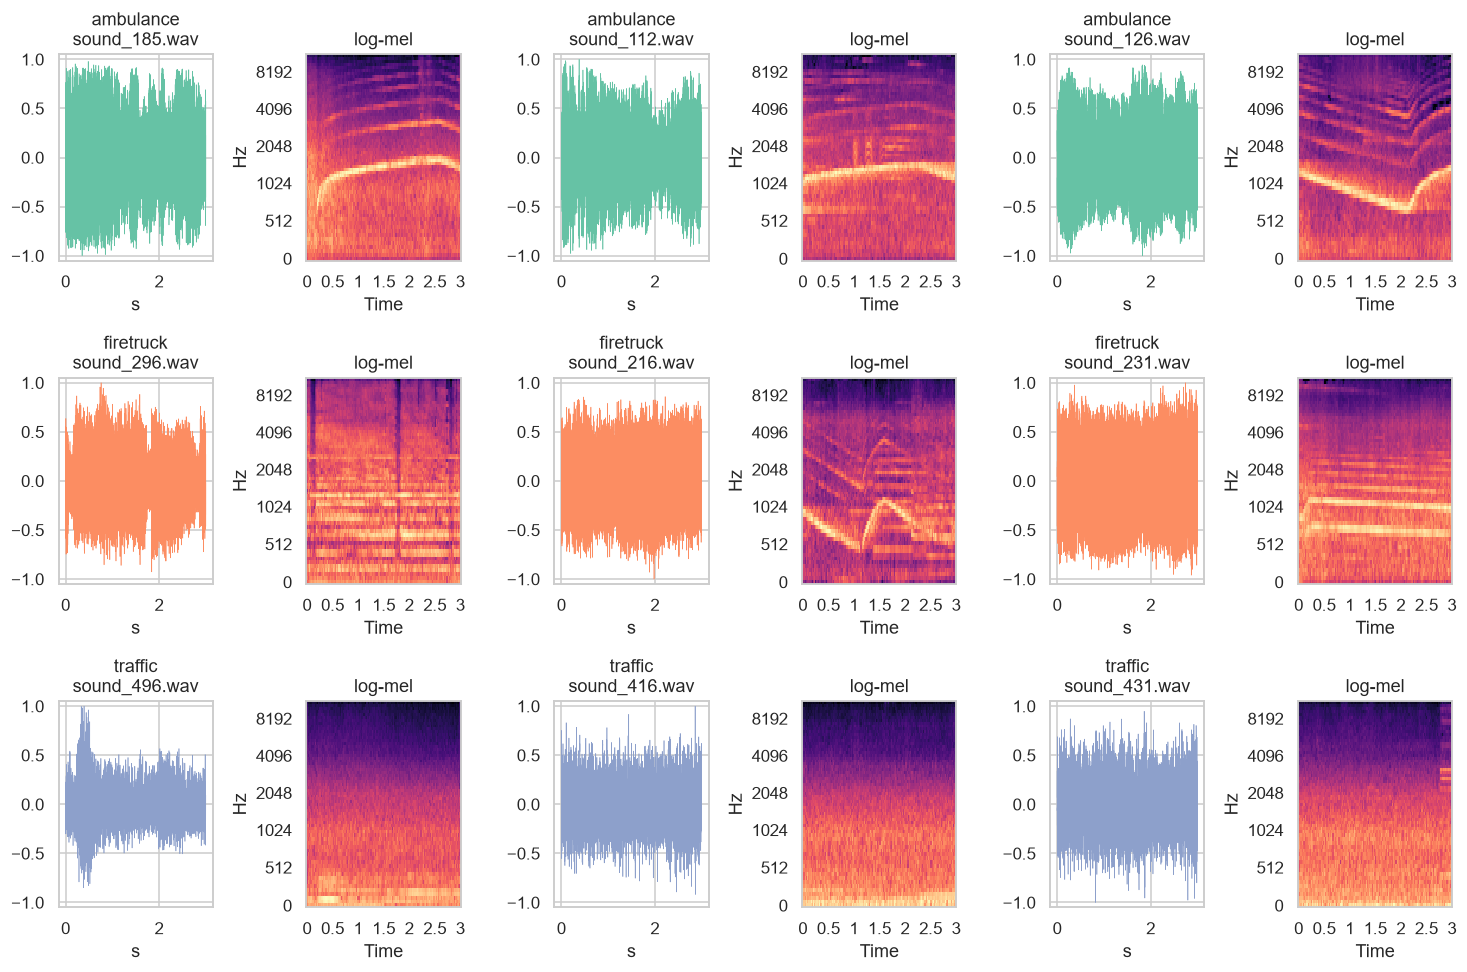

In [8]:
def logmel(y: np.ndarray) -> np.ndarray:
    mel = librosa.feature.melspectrogram(
        y=y, sr=SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS, power=2.0)
    return librosa.power_to_db(mel, ref=np.max)


N_EXAMPLES = 3
rng = np.random.default_rng(42)

fig, axes = plt.subplots(len(CLASSES), N_EXAMPLES * 2,
                         figsize=(4.5 * N_EXAMPLES, 3 * len(CLASSES)))
for r, cls in enumerate(CLASSES):
    picks = df[df.label == cls].sample(N_EXAMPLES, random_state=42)
    for c, (_, rec) in enumerate(picks.iterrows()):
        y = load_audio(rec.path)
        ax_w, ax_s = axes[r, c * 2], axes[r, c * 2 + 1]
        ax_w.plot(np.linspace(0, len(y) / SR, len(y)), y,
                  lw=0.4, color=PALETTE[cls])
        ax_w.set(ylim=(-1.05, 1.05), title=f"{cls}\n{rec.filename}", xlabel="s")
        librosa.display.specshow(logmel(y), sr=SR, hop_length=HOP,
                                 x_axis="time", y_axis="mel", ax=ax_s)
        ax_s.set_title("log-mel")
plt.tight_layout()
plt.savefig(FIG_DIR / "waveform_spectrogram.png", bbox_inches="tight")
plt.show()

---
## 6 · Ciri akustik per kelas

Empat fitur ringkas yang murah dihitung dan mudah ditafsirkan:

| Fitur | Arti | Ekspektasi |
|---|---|---|
| **RMS** | energi rata-rata | traffic lebih rata, sirine berfluktuasi |
| **Zero-crossing rate** | seberapa sering sinyal ganti tanda → proxy "kekasaran" | noise tinggi, nada tinggi juga |
| **Spectral centroid** | titik berat frekuensi → proxy "kecerahan" | sirine lebih tinggi (nada melengking) |
| **Spectral bandwidth** | lebar sebaran energi | traffic lebar (noise), sirine sempit (harmonik) |

Kalau boxplot ketiga kelas saling tumpang tindih total, artinya fitur sederhana tidak cukup —
itu justru pembenaran untuk memakai CNN di atas spektrogram.

In [9]:
def acoustic_features(path: str) -> pd.Series:
    y = load_audio(path)
    return pd.Series({
        "rms": float(librosa.feature.rms(y=y).mean()),
        "zcr": float(librosa.feature.zero_crossing_rate(y).mean()),
        "centroid": float(librosa.feature.spectral_centroid(y=y, sr=SR).mean()),
        "bandwidth": float(librosa.feature.spectral_bandwidth(y=y, sr=SR).mean()),
    })


tqdm.pandas(desc="ekstrak fitur")
feats = df.path.progress_apply(acoustic_features)
df = pd.concat([df, feats], axis=1)

df.groupby("label")[["rms", "zcr", "centroid", "bandwidth"]].agg(["mean", "std"]).round(3)


ekstrak fitur:   0%|          | 0/600 [00:00<?, ?it/s]


ekstrak fitur:   2%|▏         | 9/600 [00:00<00:07, 78.50it/s]


ekstrak fitur:   3%|▎         | 17/600 [00:00<00:08, 71.14it/s]


ekstrak fitur:   4%|▍         | 25/600 [00:00<00:08, 69.93it/s]


ekstrak fitur:   6%|▌         | 33/600 [00:00<00:09, 62.47it/s]

...


ekstrak fitur:  97%|█████████▋| 583/600 [00:08<00:00, 68.91it/s]


ekstrak fitur:  98%|█████████▊| 591/600 [00:08<00:00, 69.72it/s]


ekstrak fitur: 100%|█████████▉| 598/600 [00:08<00:00, 69.67it/s]


ekstrak fitur: 100%|██████████| 600/600 [00:08<00:00, 68.64it/s]

rms           zcr         centroid          bandwidth         
            mean    std   mean    std      mean      std      mean      std
label                                                                      
ambulance  0.297  0.090  0.112  0.020  1745.384  316.766  1529.119  359.859
firetruck  0.251  0.057  0.132  0.027  2324.403  467.241  2039.835  327.674
traffic    0.230  0.029  0.046  0.010  1043.408   97.023  1439.168   91.243

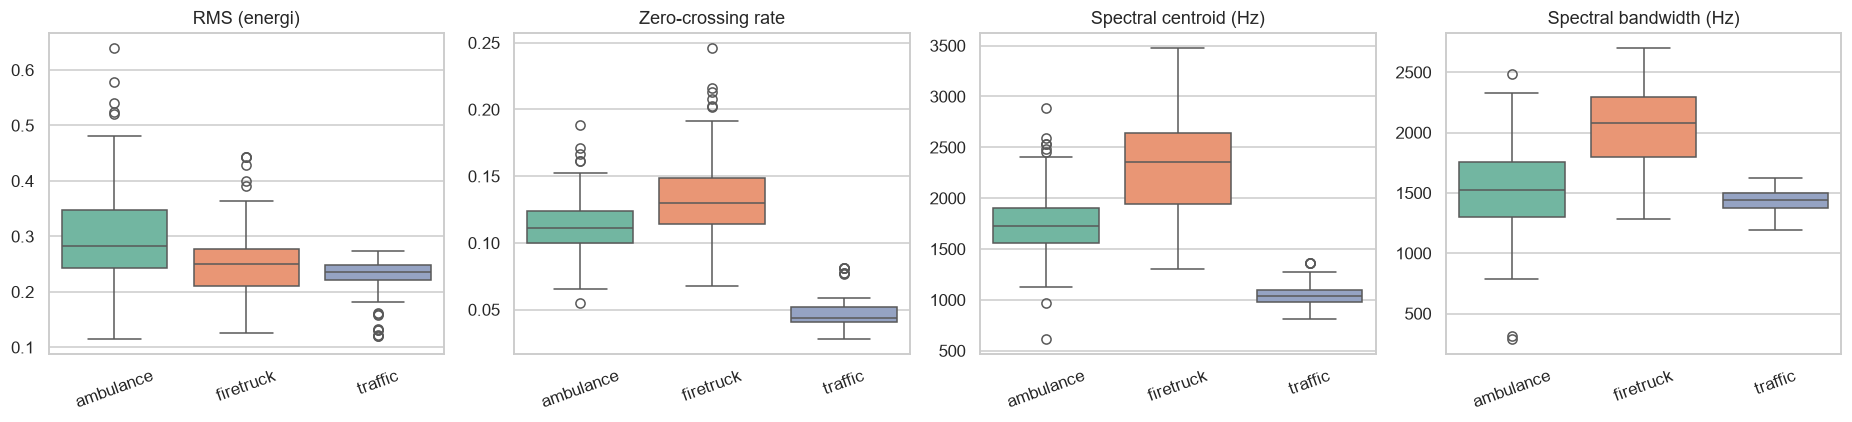

In [10]:
FEATURES = {
    "rms": "RMS (energi)",
    "zcr": "Zero-crossing rate",
    "centroid": "Spectral centroid (Hz)",
    "bandwidth": "Spectral bandwidth (Hz)",
}

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, (col, title) in zip(axes, FEATURES.items()):
    sns.boxplot(data=df, x="label", y=col, order=CLASSES,
                palette=PALETTE, hue="label", legend=False, ax=ax)
    ax.set(title=title, xlabel="", ylabel="")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "acoustic_features.png", bbox_inches="tight")
plt.show()

### Sidik jari frekuensi per kelas

Rata-rata log-mel seluruh file dalam satu kelas. Ini meratakan variasi antar-rekaman
dan menyisakan pola pita frekuensi yang khas untuk kelas tersebut.


ambulance:   0%|          | 0/100 [00:00<?, ?it/s]


ambulance:  19%|█▉        | 19/100 [00:00<00:00, 185.63it/s]


ambulance:  40%|████      | 40/100 [00:00<00:00, 195.33it/s]


ambulance:  61%|██████    | 61/100 [00:00<00:00, 197.96it/s]


ambulance:  83%|████████▎ | 83/100 [00:00<00:00, 204.59it/s]

...


traffic:   0%|          | 0/100 [00:00<?, ?it/s]


traffic:  21%|██        | 21/100 [00:00<00:00, 205.67it/s]


traffic:  42%|████▏     | 42/100 [00:00<00:00, 201.40it/s]


traffic:  63%|██████▎   | 63/100 [00:00<00:00, 202.17it/s]


traffic:  84%|████████▍ | 84/100 [00:00<00:00, 204.09it/s]

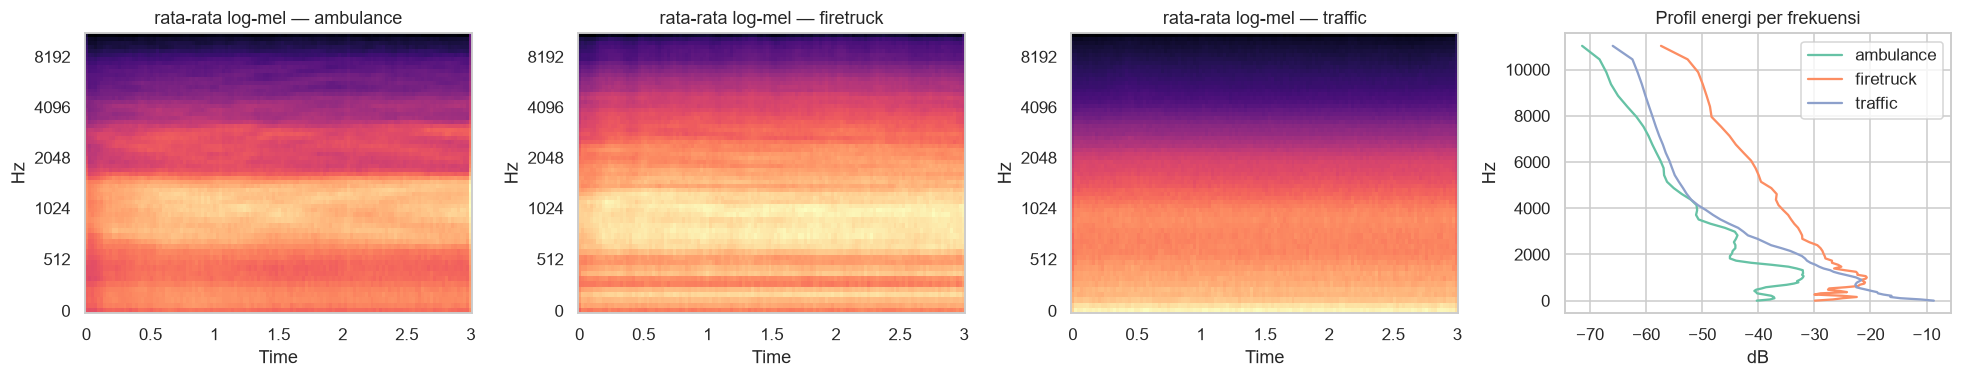

In [11]:
MAX_PER_CLASS = 100          # naikkan kalau mau lebih presisi (lebih lambat)

profiles = {}
for cls in CLASSES:
    paths = df[df.label == cls].path.sample(
        min(MAX_PER_CLASS, (df.label == cls).sum()), random_state=42)
    spec = np.stack([logmel(load_audio(p))
                     for p in tqdm(paths, desc=cls, leave=False)])
    profiles[cls] = spec.mean(axis=0)          # rata-rata antar file

mel_hz = librosa.mel_frequencies(n_mels=N_MELS, fmin=0, fmax=SR // 2)

fig, axes = plt.subplots(1, len(CLASSES) + 1,
                         figsize=(4.5 * (len(CLASSES) + 1), 3.6))
for ax, cls in zip(axes, CLASSES):
    librosa.display.specshow(profiles[cls], sr=SR, hop_length=HOP,
                             x_axis="time", y_axis="mel", ax=ax)
    ax.set_title(f"rata-rata log-mel — {cls}")

for cls in CLASSES:
    axes[-1].plot(profiles[cls].mean(axis=1), mel_hz,
                  label=cls, color=PALETTE[cls])
axes[-1].set(title="Profil energi per frekuensi", xlabel="dB", ylabel="Hz")
axes[-1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "frequency_profile.png", bbox_inches="tight")
plt.show()

---
## 7 · Ringkasan

Sel di bawah mencetak temuan sebagai teks supaya gampang disalin ke laporan KP.

In [12]:
n_dup = int(df.md5.duplicated().sum())
n_sr = df.sample_rate.nunique()
n_stereo = int((df.channels == 2).sum())

print("=" * 62)
print("RINGKASAN EDA — DATASET 1")
print("=" * 62)
print(f"Total file          : {len(df)} ({len(df) - n_dup} unik)")
print(f"Kelas               : {', '.join(CLASSES)}")
print(f"Per kelas           : {counts.to_dict()}")
print(f"File corrupt        : {len(corrupt)}")
print(f"File duplikat       : {n_dup}")
print(f"File senyap         : {len(silent)}")
print(f"Sample rate         : {n_sr} nilai berbeda → {sorted(df.sample_rate.dropna().unique())}")
print(f"Stereo              : {n_stereo}/{len(df)}")
print(f"Durasi              : {df.duration.min():.2f}–{df.duration.max():.2f} s "
      f"(median {df.duration.median():.2f})")
print("-" * 62)
print("IMPLIKASI PREPROCESSING")
print(f"  • resample ke {SR} Hz  → {'WAJIB' if n_sr > 1 else 'opsional'}")
print(f"  • konversi mono       → {'WAJIB' if n_stereo else 'tidak perlu'}")
print(f"  • pad/crop ke {DURATION}s   → "
      f"{'perlu' if len(df[(df.duration - DURATION).abs() > 0.05]) else 'tidak perlu (durasi sudah seragam)'}")
print(f"  • drop duplikat       → {'ya, ' + str(n_dup) + ' file' if n_dup else 'tidak ada'}")
print("  • peak normalize      → ya (samakan level antar rekaman)")
print("=" * 62)

# simpan inventaris lengkap untuk dipakai notebook berikutnya
out = ROOT / "ml" / "eda_dataset1.csv"
out.parent.mkdir(parents=True, exist_ok=True)
df.drop(columns=["path"]).to_csv(out, index=False)
print(f"\ninventaris tersimpan → {out}")

RINGKASAN EDA — DATASET 1
Total file          : 600 (596 unik)
Kelas               : ambulance, firetruck, traffic
Per kelas           : {'ambulance': 200, 'firetruck': 200, 'traffic': 200}
File corrupt        : 0
File duplikat       : 4
File senyap         : 0
Sample rate         : 3 nilai berbeda → [np.int64(22050), np.int64(44100), np.int64(48000)]
Stereo              : 585/600
Durasi              : 3.00–3.02 s (median 3.00)
--------------------------------------------------------------
IMPLIKASI PREPROCESSING
  • resample ke 22050 Hz  → WAJIB
  • konversi mono       → WAJIB
  • pad/crop ke 3.0s   → tidak perlu (durasi sudah seragam)
  • drop duplikat       → ya, 4 file
  • peak normalize      → ya (samakan level antar rekaman)

inventaris tersimpan → d:\Coding Vscode\Siren Classification\ml\eda_dataset1.csv


---

**Catatan untuk D1:** dataset ini tidak punya kelas `police`, jadi tidak bisa dipakai untuk training
model produksi 4-kelas. Perannya khusus sebagai *training set kondisi bersih* di robustness study —
lihat [`02_eda_dataset2.ipynb`](02_eda_dataset2.ipynb) untuk dataset produksinya.